In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [5]:
import pandas as pd

df = pd.read_csv('customer_support_text_classification.csv')
df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [6]:
print("Total Records:", len(df))
print("\nColumns:", df.columns)
print("\nClass Distribution:\n", df.iloc[:, -1].value_counts())

Total Records: 1500

Columns: Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Class Distribution:
 urgent_flag
0    1100
1     400
Name: count, dtype: int64


In [7]:
df.sample(5)

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
874,TKT00875,chat,I want to understand the warranty terms for th...,neutral,16,1
173,TKT00174,email,I would like to know more about the available ...,neutral,10,0
1157,TKT01158,phone,The router keeps failing and support has not r...,negative,16,0
1427,TKT01428,chat,The installation was completed on time and eve...,positive,15,0
320,TKT00321,chat,The delivery was late and the package arrived ...,negative,9,0


In [8]:
df['text_length'] = df.iloc[:, 0].apply(len)

print("Average Text Length:", df['text_length'].mean())

Average Text Length: 8.0


In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [11]:
def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back
    text = " ".join(tokens)

    return text

In [13]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
df['clean_text'] = df['customer_message'].apply(clean_text)

In [15]:
df['clean_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'clean_text']].head()

,customer_message,clean_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


Machine learning models cannot understand raw text directly.
They require numerical input.

Text vectorization converts words into numerical representations
so that algorithms can identify patterns, relationships,
and important features from the text data.

In [17]:
X = df['clean_text']
y = df['sentiment_label']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [20]:
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [21]:
y_pred = model.predict(X_test_tfidf)

In [23]:
print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score:
1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [25]:
from sklearn.metrics import confusion_matrix

In [26]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [28]:
import seaborn as sns

In [29]:
import matplotlib.pyplot as plt

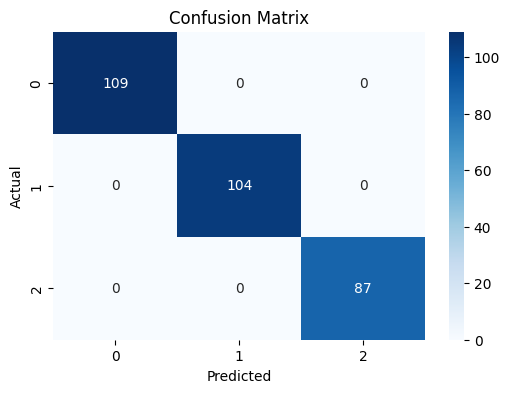

In [30]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

In [33]:
!pip install tensorflow

In [34]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [35]:
max_len = 50

X_seq = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [36]:
max_len = 50

X_seq = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [37]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [38]:
lstm_model = Sequential([

    Embedding(input_dim=5000, output_dim=128, input_length=max_len),

    LSTM(64),

    Dense(32, activation='relu'),

    Dense(len(np.unique(y_encoded)), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [39]:
lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [42]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [43]:
max_len = 50

X_seq = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

In [44]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df['sentiment_label'])

In [45]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [46]:
print(X_train_seq.shape)
print(y_train_seq.shape)

(1200, 50)
(1200,)


In [47]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq)
)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.3350 - loss: 1.1029 - val_accuracy: 0.3633 - val_loss: 1.0958
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.3417 - loss: 1.0990 - val_accuracy: 0.3467 - val_loss: 1.1019
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.3500 - loss: 1.0994 - val_accuracy: 0.3467 - val_loss: 1.1006
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3408 - loss: 1.0990 - val_accuracy: 0.3467 - val_loss: 1.0989
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.3500 - loss: 1.0994 - val_accuracy: 0.3467 - val_loss: 1.1004


In [48]:
loss, accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)

print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3467 - loss: 1.1004
Test Accuracy: 0.3466666638851166


"I need help with my order"
→ [12, 45, 87, 5, 19]

LSTM Architecture Explanation
Input Sequence

The input text is converted into integer sequences using a tokenizer.

Example:

"I need help with my order"
→ [12, 45, 87, 5, 19]
Embedding Layer

The embedding layer converts integer tokens into dense vectors.

It helps the model learn semantic relationships between words.

LSTM Layer

The LSTM processes text sequentially and remembers important contextual information.

It helps preserve long-term dependencies better than standard RNNs.

Output Layer

The dense output layer predicts the probability of each sentiment class.

Softmax activation is used for multi-class classification.

Loss Function

sparse_categorical_crossentropy

Used because labels are integer encoded.

Evaluation Metric

Accuracy is used to evaluate classification performance.

Why RNNs Struggle with Long-Term Dependencies

Standard RNNs suffer from vanishing gradients.
As sequences become longer, earlier information gets forgotten,
making it difficult to learn long-range relationships.

How LSTMs Help with Memory

LSTMs introduce memory cells and gating mechanisms
(input gate, forget gate, output gate).

These help preserve important information over longer sequences.

What Attention Solves

Attention allows the model to focus on the most relevant words
in the input sequence while generating predictions.

Instead of compressing everything into one hidden state,
attention dynamically selects important information.

Why Transformers are Important

Transformers process sequences in parallel and rely heavily on attention mechanisms.

They solve scalability and long-range dependency problems found in RNNs.

Modern NLP systems like BERT, GPT, and generative AI models
are based on transformer architectures.

In [50]:
predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

predictions.to_csv("sample_predictions.txt", index=False)